In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mglearn
import numpy as np
from sklearn.model_selection import train_test_split

w[0]: 0.393906  b: -0.031804


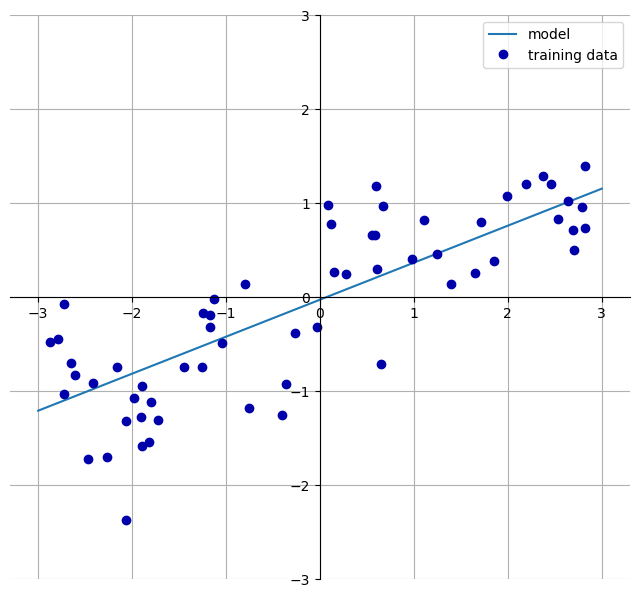

In [2]:
mglearn.plots.plot_linear_regression_wave()

In [3]:
from sklearn.linear_model import LinearRegression
X,y = mglearn.datasets.make_wave(n_samples=60)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)
lr = LinearRegression().fit(X_train,y_train)

In [4]:
print(f"lr.coef_:{lr.coef_}")
print(f"lr.intercept_:{lr.intercept_}")

lr.coef_:[0.39390555]
lr.intercept_:-0.03180434302675973


In [5]:
print(f"Training set Score:{lr.score(X_train,y_train)}")
print(f"Test set score:{lr.score(X_test,y_test)}")

Training set Score:0.6700890315075756
Test set score:0.6593368596863701


In [6]:
from sklearn.datasets import fetch_california_housing

# load_boston() の代わりに fetch_california_housing() を使います
california = fetch_california_housing()
print(f"Data shape {california.data.shape}")

Data shape (20640, 8)


In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

# 1. カリフォルニアデータの読み込み
california = fetch_california_housing()
X, y = california.data, california.target

# 2. データの正規化（0〜1の範囲にスケーリング）
X_scaled = MinMaxScaler().fit_transform(X)

# 3. 特徴量の拡張（2乗項や特徴量同士の掛け合わせを作成）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_extended_california = poly.fit_transform(X_scaled)

print(f"元の特徴量数: {X.shape[1]}")
print(f"拡張後の特徴量数: {X_extended_california.shape[1]}")

元の特徴量数: 8
拡張後の特徴量数: 44


In [8]:
X_train,X_test,y_train,y_test = train_test_split(X_extended_california,y,random_state=0)
lr = LinearRegression().fit(X_train,y_train)

In [9]:
print(f"Training set score:{lr.score(X_train,y_train)}")
print(f"Test set score:{lr.score(X_test,y_test)}")

Training set score:0.6859342166230965
Test set score:-0.7296138888213979


In [10]:
from sklearn.linear_model import Ridge
ridge = Ridge().fit(X_train,y_train)
print(f"Training set score:{ridge.score(X_train,y_train)}")
print(f"Tetst set score:{ridge.score(X_test,y_test)}")

Training set score:0.6264473905922332
Tetst set score:0.6082724341793398


In [11]:
ridge10 = Ridge(alpha=10).fit(X_train,y_train)
print(f"Training set score:{ridge10.score(X_train,y_train)}")
print(f"Tet set score:{ridge10.score(X_test,y_test)}")

Training set score:0.6081878403418599
Tet set score:0.5853167083411199


In [12]:
ridge01 = Ridge(alpha=0.1).fit(X_train,y_train)
print(f"Training set score:{ridge01.score(X_train,y_train)}")
print(f"Tet set score:{ridge01.score(X_test,y_test)}")

Training set score:0.6457691215129189
Tet set score:0.6286192931794674


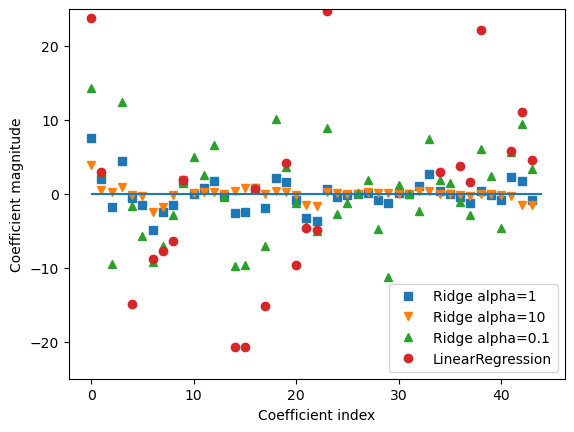

In [13]:
plt.plot(ridge.coef_,'s',label="Ridge alpha=1")
plt.plot(ridge10.coef_,'v',label="Ridge alpha=10")
plt.plot(ridge01.coef_,'^',label="Ridge alpha=0.1")

plt.plot(lr.coef_,'o',label='LinearRegression')
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")

plt.hlines(0,0,len(ridge.coef_))
plt.ylim(-25,25)
plt.legend()

In [15]:
mglearn.plots.plot_ridge_n_samples()

HTTPError: HTTP Error 403: Forbidden

In [16]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_train,y_train)
print(f"Training set score:{lasso.score(X_train,y_train)}")
print(f"Testing set score:{lasso.score(X_test,y_test)}")
print(f"Number of features used:{np.sum(lasso.coef_ !=0)}")

Training set score:0.0
Testing set score:-0.0004092193772518016
Number of features used:0


In [17]:
lasso001 = Lasso(alpha=0.01,max_iter=1000000).fit(X_train,y_train)
print(f"Training set score:{lasso001.score(X_train,y_train)}")
print(f"Test set score:{lasso001.score(X_test,y_test)}")
print(f"Number of features used:{np.sum(lasso001.coef_ !=0)}")

Training set score:0.5562169056762745
Test set score:0.5317229402994341
Number of features used:4


In [18]:
lasso00001 = Lasso(alpha=0.0001,max_iter=1000000).fit(X_train,y_train)
print(f"Training set score:{lasso00001.score(X_train,y_train)}")
print(f"Test set score:{lasso00001.score(X_test,y_test)}")
print(f"Number of features used:{np.sum(lasso00001.coef_ !=0)}")

Training set score:0.6368414962782822
Test set score:0.6217806949241769
Number of features used:19


Text(0, 0.5, 'Coefficient magnitude')

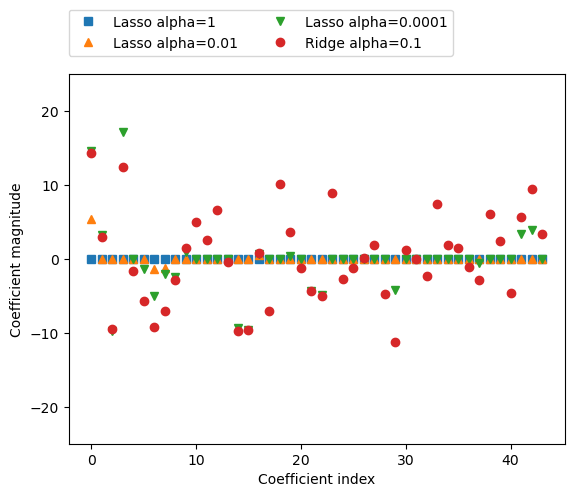

In [19]:
plt.plot(lasso.coef_,'s',label='Lasso alpha=1')
plt.plot(lasso001.coef_,'^',label='Lasso alpha=0.01')
plt.plot(lasso00001.coef_,'v',label='Lasso alpha=0.0001')
plt.plot(ridge01.coef_,'o',label='Ridge alpha=0.1')
plt.legend(ncol=2,loc=(0,1.05))
plt.ylim(-25,25)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")

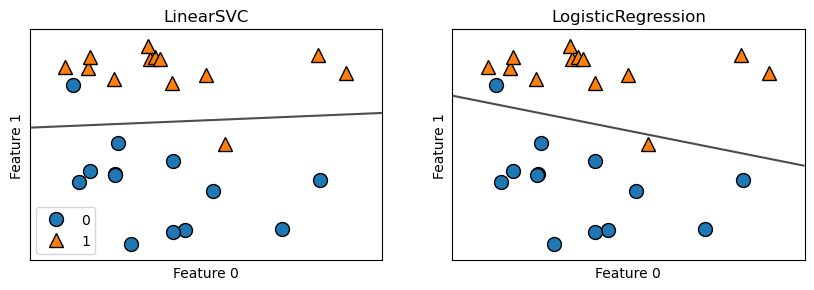

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
X,y = mglearn.datasets.make_forge()
fig,axes = plt.subplots(1,2,figsize=(10,3))
for model,ax in zip([LinearSVC(),LogisticRegression()],axes):
    clf = model.fit(X,y)
    mglearn.plots.plot_2d_separator(clf,X,fill=False,eps=0.5,ax=ax,alpha=0.7)
    mglearn.discrete_scatter(X[:,0],X[:,1],y,ax=ax)
    ax.set_title(f"{clf.__class__.__name__}")
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
axes[0].legend()

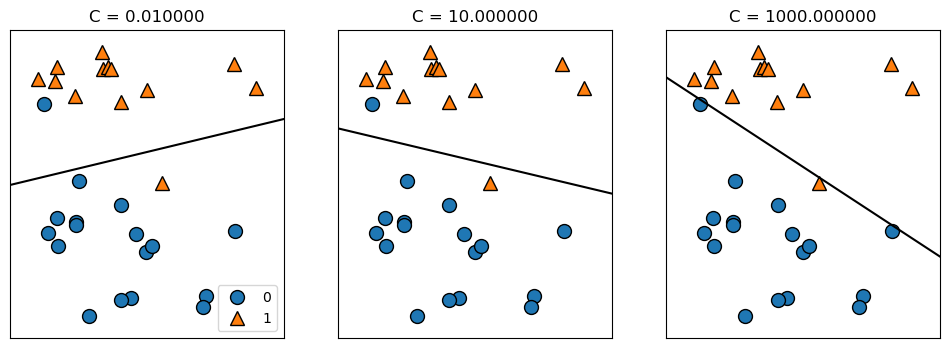

In [21]:
mglearn.plots.plot_linear_svc_regularization()

In [36]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,stratify=cancer.target,random_state=42)
logreg100 = LogisticRegression(C=100,max_iter=10**6).fit(X_train,y_train)
print(f"Training set score:{logreg100.score(X_train,y_train)}")
print(f"Test set score:{logreg100.score(X_test,y_test)}")

Training set score:0.9812206572769953
Test set score:0.972027972027972


In [37]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,stratify=cancer.target,random_state=42)
logreg = LogisticRegression(max_iter=10**6).fit(X_train,y_train)
print(f"Training set score:{logreg.score(X_train,y_train)}")
print(f"Test set score:{logreg.score(X_test,y_test)}")

Training set score:0.9577464788732394
Test set score:0.958041958041958


In [38]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,stratify=cancer.target,random_state=42)
logreg001 = LogisticRegression(C=0.01,max_iter=10**6).fit(X_train,y_train)
print(f"Training set score:{logreg001.score(X_train,y_train)}")
print(f"Test set score:{logreg001.score(X_test,y_test)}")

Training set score:0.9530516431924883
Test set score:0.951048951048951


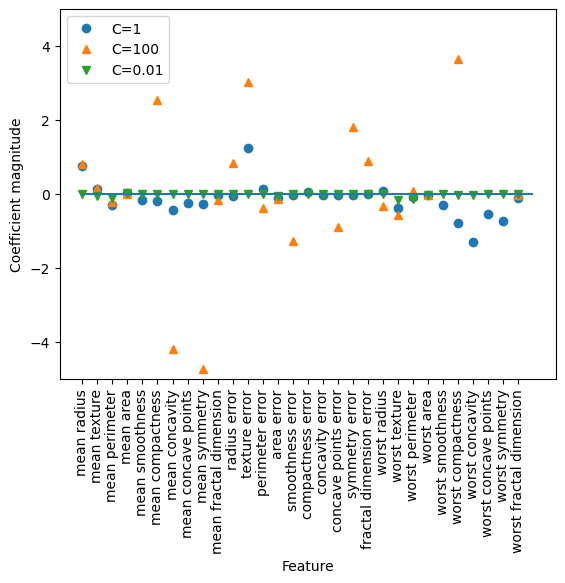

In [39]:
plt.plot(logreg.coef_.T,'o',label="C=1")
plt.plot(logreg100.coef_.T,'^',label="C=100")
plt.plot(logreg001.coef_.T,'v',label="C=0.01")
plt.xticks(range(cancer.data.shape[1]),cancer.feature_names,rotation=90)
plt.hlines(0,0,cancer.data.shape[1])
plt.ylim(-5,5)
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")
plt.legend()

C:\Users\youta\miniconda3\envs\ml-study\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\youta\miniconda3\envs\ml-study\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\youta\miniconda3\envs\ml-study\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Training accuracy of l1 logreg with C=0.001:0.9131455399061033
Test accuracy of l1 logreg with C=0.001:0.9230769230769231
Training accuracy of l1 logreg with C=1:0.960093896713615
Test accuracy of l1 logreg with C=1:0.958041958041958
Training accuracy of l1 logreg with C=100:0.9859154929577465
Test accuracy of l1 logreg with C=100:0.9790209790209791


C:\Users\youta\miniconda3\envs\ml-study\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\youta\miniconda3\envs\ml-study\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


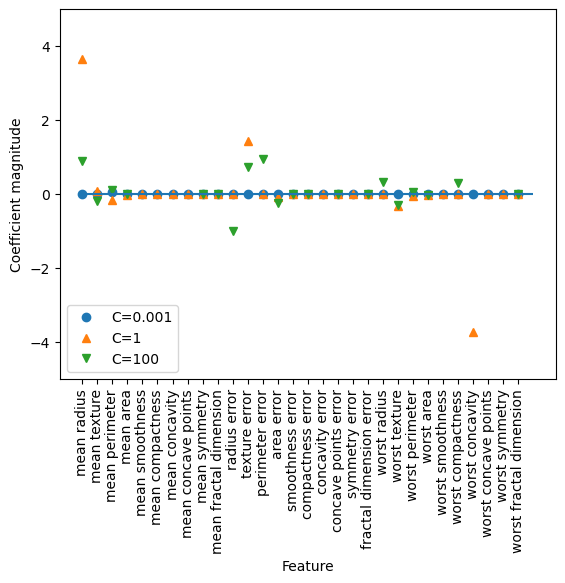

In [46]:
for C, marker in zip([0.001,1,100],['o','^','v']):
    lr_l1 = LogisticRegression(C=C,penalty="l1",solver="liblinear").fit(X_train,y_train)
    print(f"Training accuracy of l1 logreg with C={C}:{lr_l1.score(X_train,y_train)}")
    print(f"Test accuracy of l1 logreg with C={C}:{lr_l1.score(X_test,y_test)}")
    plt.plot(lr_l1.coef_.T,marker,label=f"C={C}")
plt.xticks(range(cancer.data.shape[1]),cancer.feature_names,rotation=90)
plt.hlines(0,0,cancer.data.shape[1])
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")
plt.ylim(-5,5)
plt.legend(loc=3)

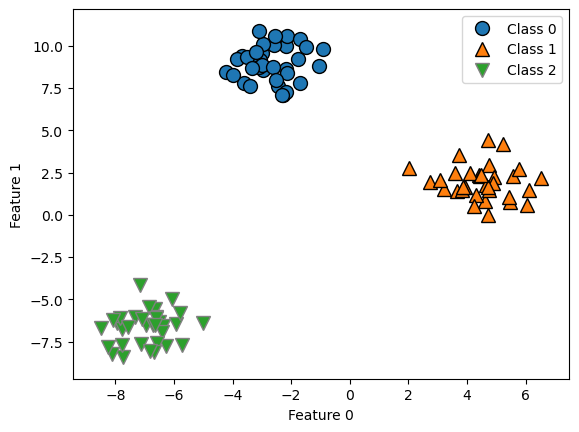

In [47]:
from sklearn.datasets import make_blobs
X,y = make_blobs(random_state=42)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0","Class 1","Class 2"])

In [50]:
linear_svm = LinearSVC().fit(X,y)
print(f"Coefficient shape:{linear_svm.coef_}")
print(f"Intercept_shape:{linear_svm.intercept_.shape}")

Coefficient shape:[[-0.17492412  0.23140766]
 [ 0.47622012 -0.06936786]
 [-0.18914207 -0.20400079]]
Intercept_shape:(3,)


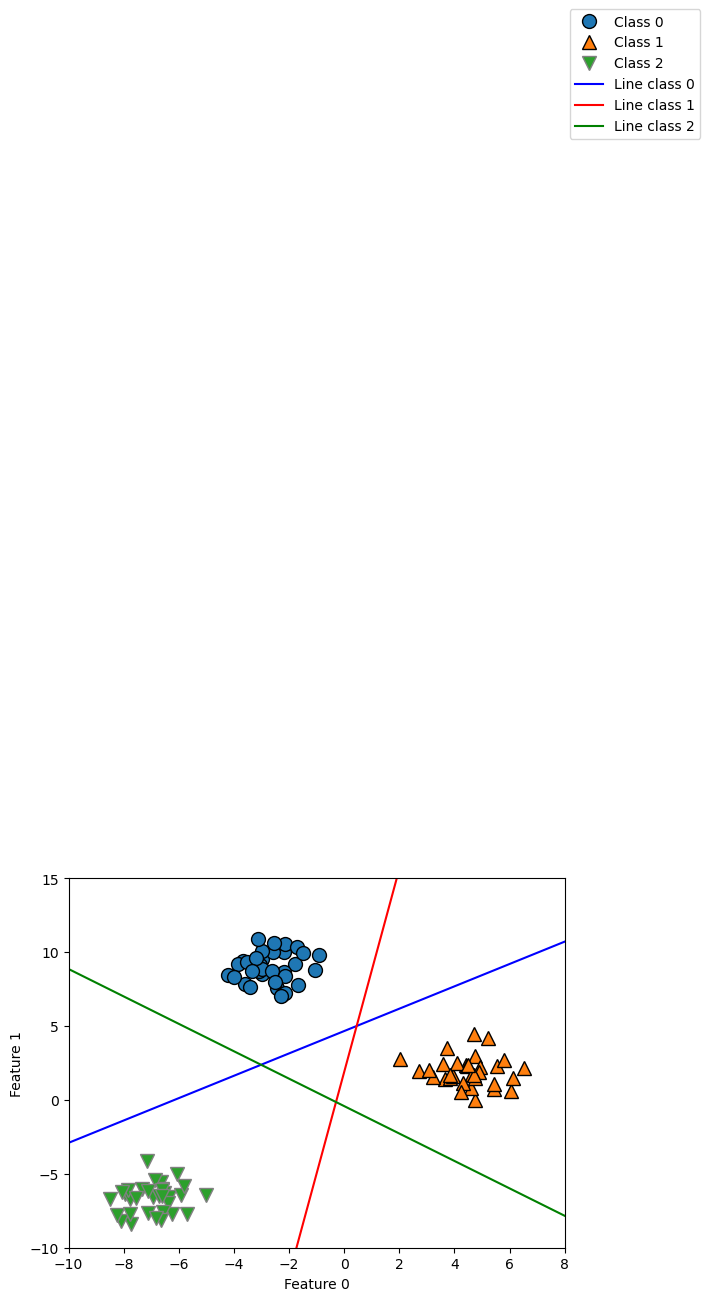

In [54]:
mglearn.discrete_scatter(X[:,0],X[:,1],y)
line = np.linspace(-15,15)
for coef,intercept,color in zip(linear_svm.coef_,linear_svm.intercept_,['b','r','g']):
    plt.plot(line,-(line * coef[0] + intercept)/coef[1],c=color)
    plt.ylim(-10,15)
    plt.xlim(-10,8)
    plt.xlabel("Feature 0")
    plt.ylabel("Feature 1")
    plt.legend(['Class 0','Class 1','Class 2','Line class 0','Line class 1','Line class 2'],loc=(1.01,3))

Text(0, 0.5, 'Feature 1')

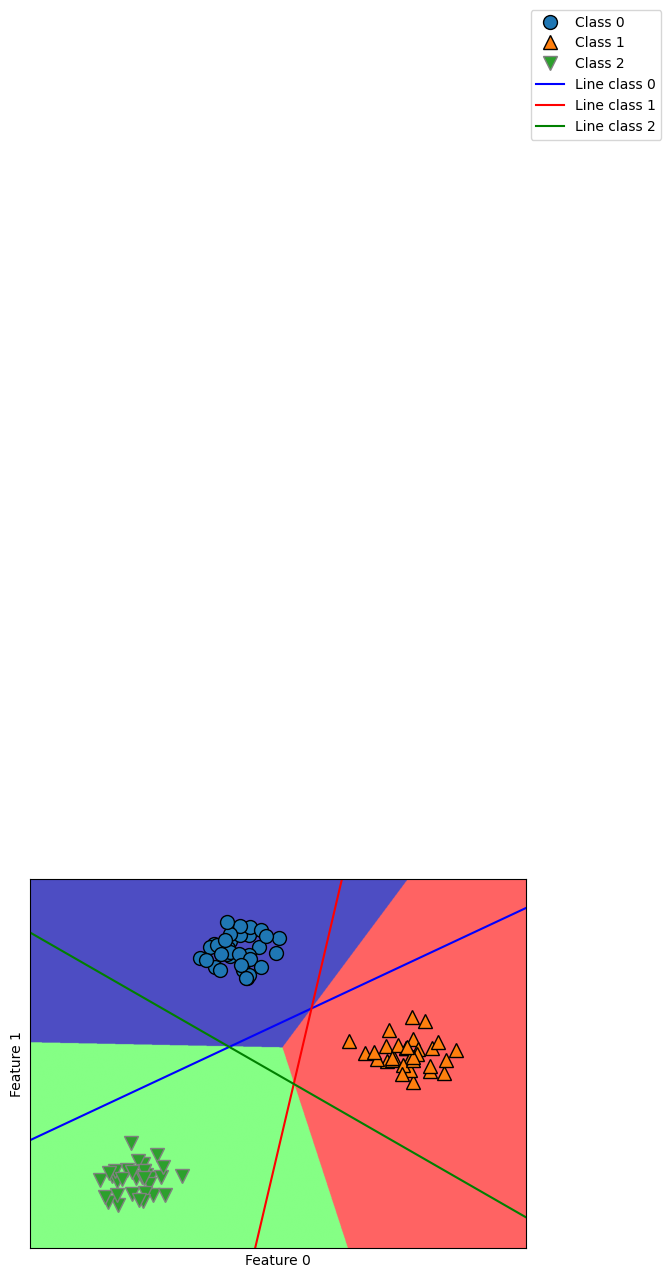

In [55]:
mglearn.plots.plot_2d_classification(linear_svm,X,fill=True,alpha=.7)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
line=np.linspace(-15,15)
for coef,intercept,color in zip(linear_svm.coef_,linear_svm.intercept_,['b','r','g']):
    plt.plot(line,-(line*coef[0]+intercept)/coef[1],color=color)
plt.legend(['Class 0','Class 1','Class 2','Line class 0','Line class 1','Line class 2'],loc=(1.01,3))
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")